# Monotonic GNN — Layer Depth Analysis

This notebook compares MGNN runs at L = 1, 2, and 3 layers across:
- **Predictive performance** (F1, AUPRC, precision, recall)
- **Threshold sensitivity** (precision-recall curves)
- **Prediction volume** (how many facts each model derives)
- **Rule complexity** (body length, unique predicates, rule types)
- **Rule generality** (do deeper models produce shorter, more general rules?)

Research question: *Does increasing GNN depth (L = 1 → 2 → 3) produce shorter, more general rules or longer, more specific ones?*

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import re
import warnings
warnings.filterwarnings("ignore")

plt.rcParams.update({
    "figure.dpi": 120,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 11,
})

# Experiments folders
LAYER_1_DIR = Path("./layer1") 
LAYER_2_DIR = Path("./layer2")  
LAYER_3_DIR = Path("./layer3") 

RUNS = {
    "L=1": LAYER_1_DIR,
    "L=2": LAYER_2_DIR,
    "L=3": LAYER_3_DIR,
}

COLOURS = {"L=1": "#4C72B0", "L=2": "#DD8452", "L=3": "#55A868"}

## 1. Load Metrics

In [2]:
def load_metrics(path: Path) -> tuple[pd.DataFrame, float]:
    """Parse a metrics file. Returns (DataFrame of per-threshold rows, AUPRC float)."""
    lines = path.read_text().splitlines()
    auprc_line = [l for l in lines if l.startswith("Area")][0]
    auprc = float(auprc_line.split(":")[1].strip())
    data_lines = [l for l in lines if not l.startswith("Area") and not l.startswith("Threshold")]
    rows = []
    for line in data_lines:
        parts = line.split("\t")
        if len(parts) == 5:
            threshold, precision, recall, accuracy, f1 = parts
            rows.append({
                "threshold": float(threshold),
                "precision": float(precision) if precision != "nan" else np.nan,
                "recall":    float(recall)    if recall    != "nan" else np.nan,
                "accuracy":  float(accuracy)  if accuracy  != "nan" else np.nan,
                "f1":        float(f1)        if f1        != "nan" else np.nan,
            })
    return pd.DataFrame(rows), auprc


test_metrics  = {}
valid_metrics = {}
auprcs        = {}

for label, folder in RUNS.items():
    test_df,  test_auprc  = load_metrics(folder / "test_metrics.txt")
    valid_df, valid_auprc = load_metrics(folder / "valid_metrics.txt")
    test_metrics[label]   = test_df
    valid_metrics[label]  = valid_df
    auprcs[label]         = {"test": test_auprc, "valid": valid_auprc}
    best_f1 = test_df["f1"].max()
    best_thresh = test_df.loc[test_df["f1"].idxmax(), "threshold"]
    print(f"{label}  |  Test AUPRC: {test_auprc:.4f}  |  Best Test F1: {best_f1:.4f} @ threshold {best_thresh}")

L=1  |  Test AUPRC: 0.9387  |  Best Test F1: 0.9560 @ threshold 0.13
L=2  |  Test AUPRC: 0.9391  |  Best Test F1: 0.9560 @ threshold 0.02
L=3  |  Test AUPRC: 0.9390  |  Best Test F1: 0.9560 @ threshold 0.02


## 2. Predictive Performance Summary

Best F1 and AUPRC per depth, on both test and validation sets.

In [3]:
summary_rows = []
for label in RUNS:
    t = test_metrics[label]
    v = valid_metrics[label]
    best_test_row  = t.loc[t["f1"].idxmax()]
    best_valid_row = v.loc[v["f1"].idxmax()]
    summary_rows.append({
        "Depth":             label,
        "Test AUPRC":        round(auprcs[label]["test"],  4),
        "Test Best F1":      round(best_test_row["f1"],    4),
        "Test Precision":    round(best_test_row["precision"], 4),
        "Test Recall":       round(best_test_row["recall"],    4),
        "Test Threshold":    best_test_row["threshold"],
        "Valid AUPRC":       round(auprcs[label]["valid"], 4),
        "Valid Best F1":     round(best_valid_row["f1"],   4),
    })

summary_df = pd.DataFrame(summary_rows).set_index("Depth")
summary_df

,Test AUPRC,Test Best F1,Test Precision,Test Recall,Test Threshold,Valid AUPRC,Valid Best F1
Depth,,,,,,,
L=1,0.9387,0.956,0.9935,0.9212,0.13,0.1188,0.1007
L=2,0.9391,0.956,0.9935,0.9212,0.02,0.1229,0.1007
L=3,0.9390,0.956,0.9935,0.9212,0.02,0.1229,0.1007


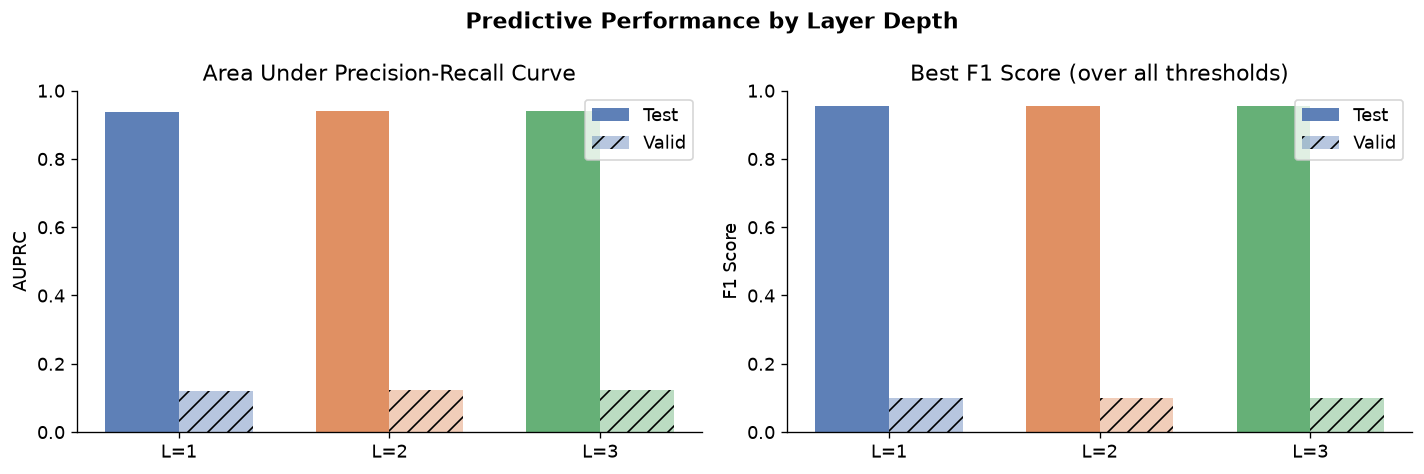

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

labels = list(RUNS.keys())
x = np.arange(len(labels))
width = 0.35

# AUPRC
ax = axes[0]
test_auprcs  = [auprcs[l]["test"]  for l in labels]
valid_auprcs = [auprcs[l]["valid"] for l in labels]
ax.bar(x - width/2, test_auprcs,  width, label="Test",  color=[COLOURS[l] for l in labels], alpha=0.9)
ax.bar(x + width/2, valid_auprcs, width, label="Valid", color=[COLOURS[l] for l in labels], alpha=0.4, hatch="//")
ax.set_xticks(x); ax.set_xticklabels(labels)
ax.set_ylabel("AUPRC")
ax.set_title("Area Under Precision-Recall Curve")
ax.legend()
ax.set_ylim(0, 1)

# Best F1
ax = axes[1]
test_f1s  = [summary_df.loc[l, "Test Best F1"]  for l in labels]
valid_f1s = [summary_df.loc[l, "Valid Best F1"] for l in labels]
ax.bar(x - width/2, test_f1s,  width, label="Test",  color=[COLOURS[l] for l in labels], alpha=0.9)
ax.bar(x + width/2, valid_f1s, width, label="Valid", color=[COLOURS[l] for l in labels], alpha=0.4, hatch="//")
ax.set_xticks(x); ax.set_xticklabels(labels)
ax.set_ylabel("F1 Score")
ax.set_title("Best F1 Score (over all thresholds)")
ax.legend()
ax.set_ylim(0, 1)

fig.suptitle("Predictive Performance by Layer Depth", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("performance_comparison.png", bbox_inches="tight")
plt.show()

## 3. Precision-Recall Curves

Overlaid PR curves for each depth. A curve that stays higher and further right is better.
The area under each curve is the AUPRC reported above.

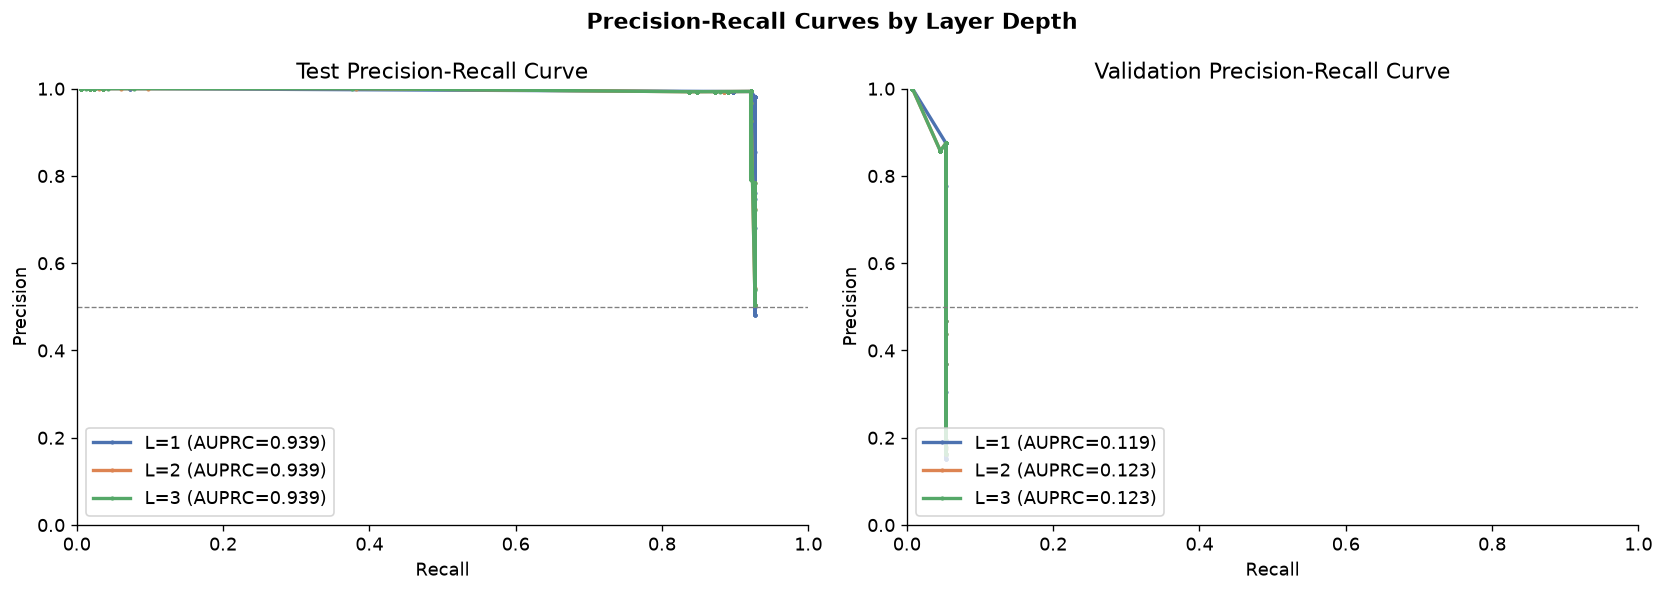

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for split, metrics_dict, auprc_key, ax in [("Test", test_metrics, "test", axes[0]), ("Validation", valid_metrics, "valid", axes[1])]:
    for label, df in metrics_dict.items():
        df_clean = df.dropna(subset=["precision", "recall"])
        df_sorted = df_clean.sort_values("recall", ascending=False)
        ax.plot(
            df_sorted["recall"], df_sorted["precision"],
            label=f"{label} (AUPRC={auprcs[label][auprc_key]:.3f})",
            color=COLOURS[label], linewidth=2, marker=".", markersize=3
        )
    ax.set_xlabel("Recall")
    ax.set_ylabel("Precision")
    ax.set_title(f"{split} Precision-Recall Curve")
    ax.legend(loc="lower left")
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    ax.axhline(0.5, linestyle="--", color="grey", linewidth=0.8, label="Random baseline")

plt.suptitle("Precision-Recall Curves by Layer Depth", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("pr_curves.png", bbox_inches="tight")
plt.show()

## 4. Threshold Sensitivity

How F1 changes as the decision threshold moves from 0 → 1.
A flatter peak suggests the model is more robust to threshold choice.
A narrow peak suggests the optimal threshold is fragile.

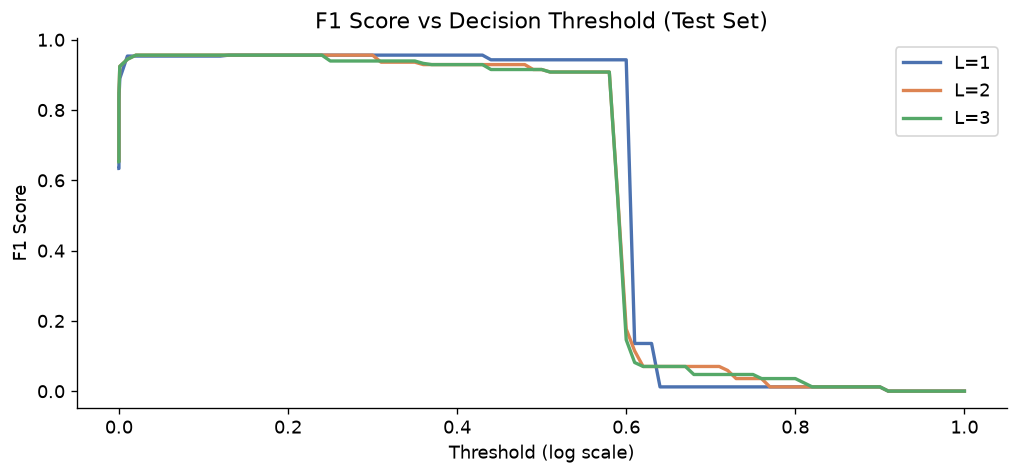

In [9]:
fig, ax = plt.subplots(figsize=(10, 4))

for label, df in test_metrics.items():
    df_clean = df.dropna(subset=["f1"])
    ax.plot(
        df_clean["threshold"], df_clean["f1"],
        label=label, color=COLOURS[label], linewidth=2
    )

ax.set_xlabel("Threshold (log scale)")
ax.set_ylabel("F1 Score")
ax.set_title("F1 Score vs Decision Threshold (Test Set)")
ax.legend()
plt.show()

## 5. Prediction Volume

How many facts does each model derive? More predictions at similar precision = more recall.
Also shows the score distribution — do deeper models produce more confident predictions?

In [10]:
def load_scored_predictions(folder: Path) -> pd.DataFrame:
    df = pd.read_csv(
        folder / "predicted_triples_scored.tsv",
        sep="\t", header=None,
        names=["subject", "relation", "object", "score"]
    )
    return df

predictions = {label: load_scored_predictions(folder) for label, folder in RUNS.items()}

for label, df in predictions.items():
    print(f"{label}: {len(df)} predicted facts | mean score: {df['score'].mean():.4f} | median: {df['score'].median():.4f}")

L=1: 21582 predicted facts | mean score: 0.0356 | median: 0.0000
L=2: 20381 predicted facts | mean score: 0.0364 | median: 0.0000
L=3: 20378 predicted facts | mean score: 0.0361 | median: 0.0000


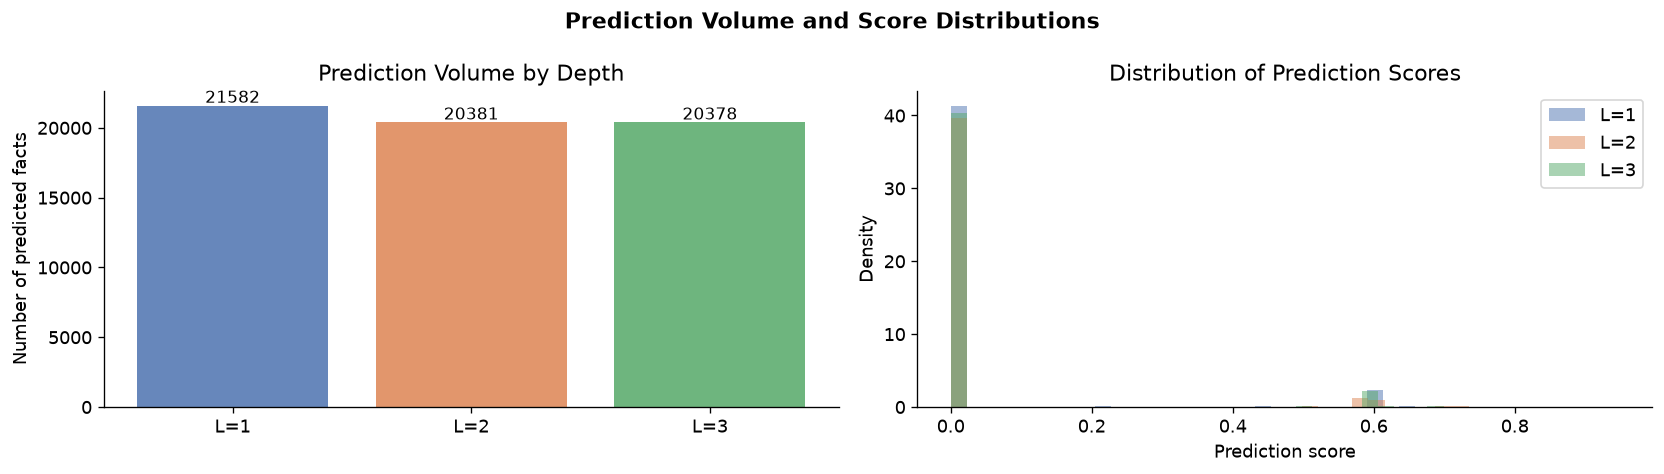

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Bar chart of prediction counts
ax = axes[0]
counts = [len(predictions[l]) for l in RUNS]
ax.bar(list(RUNS.keys()), counts, color=[COLOURS[l] for l in RUNS], alpha=0.85)
ax.set_ylabel("Number of predicted facts")
ax.set_title("Prediction Volume by Depth")
for i, v in enumerate(counts):
    ax.text(i, v + max(counts)*0.01, str(v), ha="center", fontsize=10)

# Score distributions
ax = axes[1]
for label, df in predictions.items():
    ax.hist(df["score"], bins=40, alpha=0.5, label=label, color=COLOURS[label], density=True)
ax.set_xlabel("Prediction score")
ax.set_ylabel("Density")
ax.set_title("Distribution of Prediction Scores")
ax.legend()

plt.suptitle("Prediction Volume and Score Distributions", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("prediction_volume.png", bbox_inches="tight")
plt.show()

## 6. Rule Complexity Analysis

Parses `explanations.txt` to extract rules learned by each model.

Metrics measured per rule:
- **Body length**: number of atoms in the rule body (more = more specific)
- **Unique predicates**: number of distinct predicates used (more = richer pattern)
- **Rule type**: trivial (head predicate appears in body unchanged) vs. non-trivial
- **Head arity**: whether the head is unary (classification) or binary (link prediction)

The core research question is: do deeper networks learn *shorter* (more general) rules?

In [12]:
def parse_rules(folder: Path) -> pd.DataFrame:
    """Extract structured rule data from explanations.txt."""
    text = (folder / "explanations.txt").read_text()
    blocks = [b.strip() for b in text.strip().split("\n\n") if b.strip()]

    rows = []
    for block in blocks:
        lines = block.splitlines()
        # Find the fact tuple and the rule line
        fact_line = next((l for l in lines if l.startswith("(")), None)
        rule_line = next((l for l in lines if " :- " in l), None)
        if rule_line is None:
            continue

        # Parse head and body
        head_str, body_str = rule_line.split(" :- ")
        body_str = body_str.rstrip(" .")
        body_atoms = [a.strip() for a in body_str.split(",") if a.strip()]
        body_length = len(body_atoms)

        # Extract predicate names
        pred_pattern = re.compile(r"<([^>]+)>")
        head_pred = pred_pattern.findall(head_str)
        body_preds = [p for atom in body_atoms for p in pred_pattern.findall(atom)]
        unique_body_preds = set(body_preds)

        # Is it trivial? (head predicate appears unchanged in body)
        is_trivial = (head_pred and head_pred[0] in unique_body_preds)

        # Is head binary or unary?
        head_is_binary = "," in head_str and "?" in head_str

        rows.append({
            "fact":               fact_line,
            "rule":               rule_line,
            "head_predicate":     head_pred[0] if head_pred else None,
            "body_length":        body_length,
            "unique_predicates":  len(unique_body_preds),
            "is_trivial":         is_trivial,
            "head_is_binary":     head_is_binary,
        })

    return pd.DataFrame(rows)


rules = {label: parse_rules(folder) for label, folder in RUNS.items()}

for label, df in rules.items():
    n = len(df)
    trivial = df["is_trivial"].sum()
    print(f"{label}: {n} rules | mean body length: {df['body_length'].mean():.2f} "
          f"| trivial: {trivial}/{n} ({100*trivial/n:.0f}%)")

L=1: 10 rules | mean body length: 2.00 | trivial: 6/10 (60%)
L=2: 10 rules | mean body length: 2.00 | trivial: 7/10 (70%)
L=3: 10 rules | mean body length: 2.00 | trivial: 7/10 (70%)


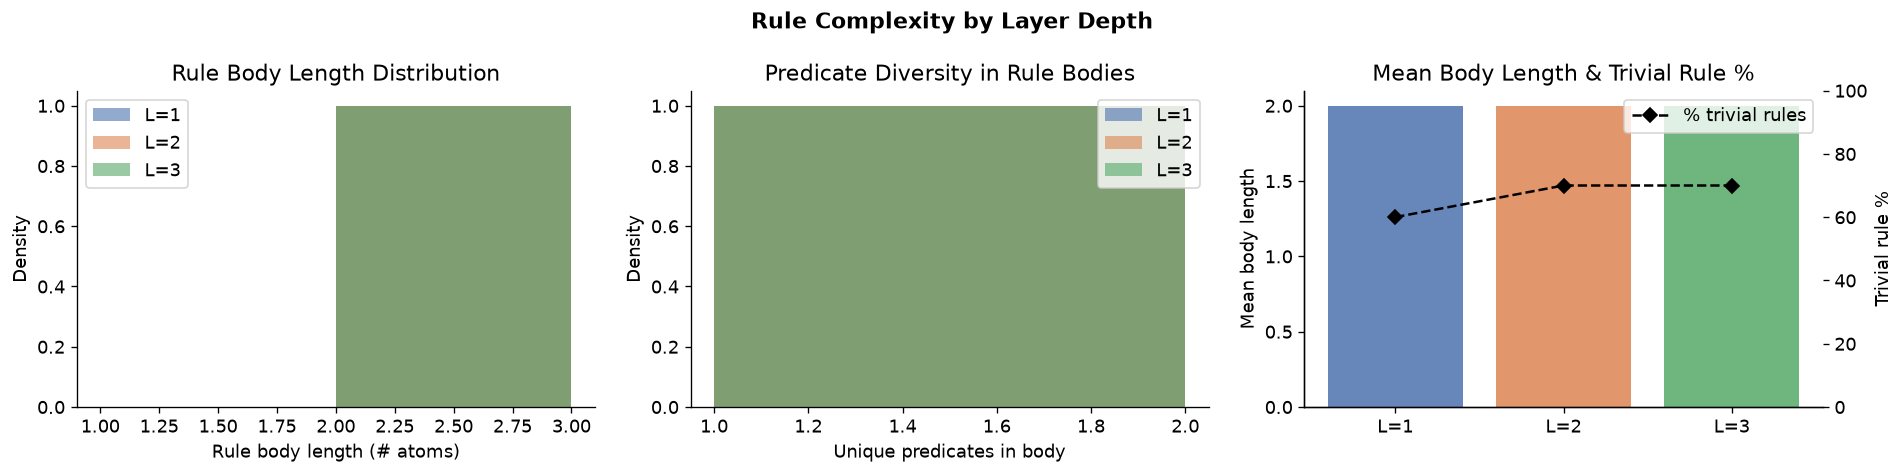

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Body length distribution
ax = axes[0]
for label, df in rules.items():
    ax.hist(df["body_length"], bins=range(1, df["body_length"].max()+2),
            alpha=0.6, label=label, color=COLOURS[label], density=True)
ax.set_xlabel("Rule body length (# atoms)")
ax.set_ylabel("Density")
ax.set_title("Rule Body Length Distribution")
ax.legend()

# Unique predicates in body
ax = axes[1]
for label, df in rules.items():
    ax.hist(df["unique_predicates"], bins=range(1, df["unique_predicates"].max()+2),
            alpha=0.6, label=label, color=COLOURS[label], density=True)
ax.set_xlabel("Unique predicates in body")
ax.set_ylabel("Density")
ax.set_title("Predicate Diversity in Rule Bodies")
ax.legend()

# Mean body length bar + trivial fraction
ax = axes[2]
labels_list = list(rules.keys())
mean_lengths = [rules[l]["body_length"].mean() for l in labels_list]
trivial_frac = [rules[l]["is_trivial"].mean() for l in labels_list]
x = np.arange(len(labels_list))
bars = ax.bar(x, mean_lengths, color=[COLOURS[l] for l in labels_list], alpha=0.85)
ax2 = ax.twinx()
ax2.plot(x, [f*100 for f in trivial_frac], "D--", color="black", label="% trivial rules", markersize=6)
ax2.set_ylabel("Trivial rule %")
ax2.set_ylim(0, 100)
ax.set_xticks(x); ax.set_xticklabels(labels_list)
ax.set_ylabel("Mean body length")
ax.set_title("Mean Body Length & Trivial Rule %")
ax2.legend(loc="upper right")

plt.suptitle("Rule Complexity by Layer Depth", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("rule_complexity.png", bbox_inches="tight")
plt.show()

## 7. Rule Generality: Head Predicate Coverage

How many distinct head predicates appear in the extracted rules?
A model that learns rules for more distinct predicates is arguably more general.
Also: which predicates are uniquely learned by each depth?

In [14]:
from collections import Counter

# Predicate coverage per depth
pred_sets = {label: set(df["head_predicate"].dropna()) for label, df in rules.items()}

for label, preds in pred_sets.items():
    print(f"{label}: {len(preds)} distinct head predicates covered")

# Unique to each depth
all_preds = set.union(*pred_sets.values())
print(f"\nTotal distinct predicates across all depths: {len(all_preds)}")
for label, preds in pred_sets.items():
    unique = preds - set.union(*[v for k, v in pred_sets.items() if k != label])
    print(f"{label} uniquely covers: {unique if unique else 'none'}")

L=1: 2 distinct head predicates covered
L=2: 2 distinct head predicates covered
L=3: 3 distinct head predicates covered

Total distinct predicates across all depths: 3
L=1 uniquely covers: none
L=2 uniquely covers: none
L=3 uniquely covers: {'_hypernym'}


In [15]:
# Per-predicate mean body length: does each depth learn simpler rules for the same predicates?
combined = []
for label, df in rules.items():
    tmp = df[["head_predicate", "body_length"]].copy()
    tmp["depth"] = label
    combined.append(tmp)
combined_df = pd.concat(combined, ignore_index=True)

# Only predicates covered by all 3 depths
shared_preds = set.intersection(*pred_sets.values())
if shared_preds:
    pivot = (
        combined_df[combined_df["head_predicate"].isin(shared_preds)]
        .groupby(["head_predicate", "depth"])["body_length"]
        .mean()
        .unstack("depth")
    )
    print("Mean body length per predicate (predicates covered by all depths):")
    display(pivot.round(2))
else:
    print("No predicates are covered by all three depths in the sampled rules.")
    print("Consider increasing the number of explained facts (currently top-10 per run).")

Mean body length per predicate (predicates covered by all depths):


depth,L=1,L=2,L=3
head_predicate,,,
_derivationally_related_form,2.0,2.0,2.0
_verb_group,2.0,2.0,2.0


## 8. Summary Table for Dissertation

Consolidated view of all key metrics for each depth.

In [16]:
dissertation_rows = []
for label in RUNS:
    t  = test_metrics[label]
    r  = rules[label]
    p  = predictions[label]
    best_row = t.loc[t["f1"].idxmax()]
    dissertation_rows.append({
        "Depth (L)":            label,
        "Test AUPRC":           round(auprcs[label]["test"],       4),
        "Test F1 (best)".ljust(18): round(best_row["f1"],          4),
        "Test Precision":       round(best_row["precision"],       4),
        "Test Recall":          round(best_row["recall"],          4),
        "Optimal Threshold":    best_row["threshold"],
        "# Predictions":        len(p),
        "Rules extracted":      len(r),
        "Mean body length":     round(r["body_length"].mean(),     2) if len(r) else None,
        "Trivial rule %":       round(r["is_trivial"].mean()*100,  1) if len(r) else None,
        "Unique predicates (mean)": round(r["unique_predicates"].mean(), 2) if len(r) else None,
    })

dissertation_df = pd.DataFrame(dissertation_rows).set_index("Depth (L)")
display(dissertation_df.T)

Depth (L),L=1,L=2,L=3
Test AUPRC,0.9387,0.9391,0.9390
Test F1 (best),0.9560,0.9560,0.9560
Test Precision,0.9935,0.9935,0.9935
Test Recall,0.9212,0.9212,0.9212
Optimal Threshold,0.1300,0.0200,0.0200
# Predictions,21582.0000,20381.0000,20378.0000
Rules extracted,10.0000,10.0000,10.0000
Mean body length,2.0000,2.0000,2.0000
Trivial rule %,60.0000,70.0000,70.0000
Unique predicates (mean),1.0000,1.0000,1.0000


In [ ]:
# Export to CSV for inclusion in dissertation
dissertation_df.to_csv("dissertation_summary.csv")
print("Saved dissertation_summary.csv")

## 9. Discussion Prompts

Use the results above to address these questions in your dissertation:

1. **Performance vs. depth**: Does adding layers improve AUPRC and F1? Is there a point of diminishing returns or degradation (overfitting)?

2. **Rule complexity vs. depth**: Does L=3 produce shorter rules than L=2? If rules are *longer* with more layers, this suggests the model is exploiting longer paths in the graph rather than finding compact generalisations.

3. **Trivial rules**: A rule like `R[?x,?y] :- R[?x,?y]` is trivially true but uninformative. If deeper models produce fewer trivial rules, they are learning more genuinely new patterns.

4. **Threshold robustness**: If one depth has a broader F1 peak (Section 4), it is less sensitive to threshold choice — practically useful for deployment.

5. **Prediction volume vs. quality**: A model that predicts far more facts but with similar F1 may be less precise. Check if the optimal-threshold precision drops as predictions scale up.

6. **Validation vs. test gap**: A large gap between validation and test AUPRC (as seen in the original 2-layer run) suggests the model generalises poorly to unseen entities. Does this gap narrow or widen with depth?

7. **Monotonicity as a constraint**: All runs use `non_negative_weights: true`. Consider: does monotonicity limit expressiveness more at deeper layers (fewer representable functions), or does the extra depth compensate?